_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: <span style='background: yellow'>*FILL IN YOUR NAMES HERE* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span>

# Project 3: Single-cell data analysis.

In [1]:
# RUN THIS
#!pip install umap-learn hdbscan pydeseq2

In [2]:
%matplotlib notebook
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import string

import scipy as sp
from scipy import sparse
import sklearn

## add your packages ##
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE, trustworthiness as sk_trustworthiness
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score
import umap
import hdbscan
import warnings
from joblib import Parallel, delayed

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder


from pydeseq2.preprocessing import deseq2_norm as pydeseq2_norm


import time
import pickle
import memory_profiler

%load_ext memory_profiler

from pathlib import Path

In [3]:
import black
import jupyter_black

jupyter_black.load(line_length=79)

In [4]:
variables_path = Path("../results/variables")
figures_path = Path("../results/figures")
data_path = Path("../data")

In [5]:
plt.style.use("../matplotlib_style.txt")

In [6]:
np.random.seed(42)

## Project and data description

In this project, we are going to work with the typical methods and pipelines used in single-cell data analysis and get some hands-on experience with the techniques used in the field. For that, we will be using Patch-seq multimodal data from cortical neurons in mice, from Scala et al. 2021 (https://www.nature.com/articles/s41586-020-2907-3#Sec7). From the different data modalities they used, we will focus on transcriptomics and electrophysiological data. 

In a real-world scenario, single cell data rarely comes with any "ground truth" labels. Often, the goal of researchers after measuring cells is to precisely classify them, grouping them into families or assigning them cell types based on the recorded features. This is normally done using usupervised methods, such as clustering methods.

However, the single-cell data that we are using in this project has some cell types assigned to each cell. These are not "ground truth" type annotations, but were one of the results from the original Scala et al. work. Still, we are going to use those annotations for validation (despite them not really being ground truth) to sanity-check some of our analyses, such as visualizations, clustering, etc. We will mainly work with cell types (`rna_types`, 77 unique types) and cell families (`rna_families`, 9 unique families).

From the transcriptomics mRNA counts, we will only work with the exon counts for simplicity. Some of the electrophysiological features are not high-quality recordings, therefore we will also filter them out.

## Import data

### Meta data

In [7]:
# META DATA

meta = pd.read_csv(data_path / "m1_patchseq_meta_data.csv", sep="\t")

cells = meta["Cell"].values

layers = meta["Targeted layer"].values.astype("str")
cre = meta["Cre"].values
yields = meta["Yield (pg/µl)"].values
yields[yields == "?"] = np.nan
yields = yields.astype("float")
depth = meta["Soma depth (µm)"].values
depth[depth == "Slice Lost"] = np.nan
depth = depth.astype(float)
thickness = meta["Cortical thickness (µm)"].values
thickness[thickness == 0] = np.nan
thickness = thickness.astype(float)
traced = meta["Traced"].values == "y"
exclude = meta["Exclusion reasons"].values.astype(str)
exclude[exclude == "nan"] = ""

mice_names = meta["Mouse"].values
mice_ages = meta["Mouse age"].values
mice_cres = np.array(
    [
        c if c[-1] != "+" and c[-1] != "-" else c[:-1]
        for c in meta["Cre"].values
    ]
)
mice_ages = dict(zip(mice_names, mice_ages))
mice_cres = dict(zip(mice_names, mice_cres))

print("Number of cells with measured depth:    ", np.sum(~np.isnan(depth)))
print("Number of cells with measured thickness:", np.sum(~np.isnan(thickness)))
print("Number of reconstructed cells:          ", np.sum(traced))

sliceids = meta["Slice"].values
a, b = np.unique(sliceids, return_counts=True)
assert np.all(b <= 2)
print("Number of slices with two cells:        ", np.sum(b == 2))

# Some consistency checks
assert np.all(
    [
        np.unique(meta["Date"].values[mice_names == m]).size == 1
        for m in mice_names
    ]
)
assert np.all(
    [
        np.unique(meta["Mouse age"].values[mice_names == m]).size == 1
        for m in mice_names
    ]
)
assert np.all(
    [
        np.unique(meta["Mouse gender"].values[mice_names == m]).size == 1
        for m in mice_names
    ]
)
assert np.all(
    [
        np.unique(meta["Mouse genotype"].values[mice_names == m]).size == 1
        for m in mice_names
    ]
)
assert np.all(
    [
        np.unique(meta["Mouse"].values[sliceids == s]).size == 1
        for s in sliceids
    ]
)

Number of cells with measured depth:     1284
Number of cells with measured thickness: 1284
Number of reconstructed cells:           646
Number of slices with two cells:         69


### "Ground truth labels"

In [8]:
# filter out low quality cells in term of RNA
print(
    "There are",
    np.sum(meta["RNA family"] == "low quality"),
    "cells with low quality RNA recordings.",
)
exclude_low_quality = meta["RNA family"] != "low quality"

There are 97 cells with low quality RNA recordings.


In [9]:
rna_family = meta["RNA family"][exclude_low_quality]
rna_type = meta["RNA type"][exclude_low_quality]

In [10]:
print(len(np.unique(rna_family)))
print(len(np.unique(rna_type)))

9
77


In [11]:
pickle_in = open(data_path / "dict_rna_type_colors.pkl", "rb")
dict_rna_type_colors = pickle.load(pickle_in)

In [12]:
rna_type_colors = np.vectorize(dict_rna_type_colors.get)(rna_type)

### Transcriptomic data

In [13]:
# READ COUNTS
data_exons = pd.read_csv(
    data_path / "m1_patchseq_exon_counts.csv.gz", na_filter=False, index_col=0
)

assert all(cells == data_exons.columns)
genes = np.array(data_exons.index)

# filter out low quality cells in term of rna family
exonCounts = data_exons.values.transpose()[exclude_low_quality]
print("Count matrix shape (exon):  ", exonCounts.shape)

Count matrix shape (exon):   (1232, 42466)


In [14]:
# GENE LENGTH

data = pd.read_csv(data_path / "gene_lengths.txt")
assert all(data["GeneID"] == genes)
exonLengths = data["exon_bp"].values

### Electrophysiological features

In [15]:
# EPHYS DATA

ephysData = pd.read_csv(data_path / "m1_patchseq_ephys_features.csv")
ephysNames = np.array(ephysData.columns[1:]).astype(str)
ephysCells = ephysData["cell id"].values
ephysData = ephysData.values[:, 1:].astype("float")
names2ephys = dict(zip(ephysCells, ephysData))
ephysData = np.array(
    [
        names2ephys[c] if c in names2ephys else ephysData[0] * np.nan
        for c in cells
    ]
)

print("Number of cells with ephys data:", np.sum(np.isin(cells, ephysCells)))

assert np.sum(~np.isin(ephysCells, cells)) == 0

Number of cells with ephys data: 1328


In [16]:
# Filtering ephys data

features_exclude = [
    "Afterdepolarization (mV)",
    "AP Fano factor",
    "ISI Fano factor",
    "Latency @ +20pA current (ms)",
    "Wildness",
    "Spike frequency adaptation",
    "Sag area (mV*s)",
    "Sag time (s)",
    "Burstiness",
    "AP amplitude average adaptation index",
    "ISI average adaptation index",
    "Rebound number of APs",
]
features_log = [
    "AP coefficient of variation",
    "ISI coefficient of variation",
    "ISI adaptation index",
    "Latency (ms)",
]

X = ephysData[exclude_low_quality]
print(X.shape)
for e in features_log:
    X[:, ephysNames == e] = np.log(X[:, ephysNames == e])
X = X[:, ~np.isin(ephysNames, features_exclude)]

keepcells = ~np.isnan(np.sum(X, axis=1))
X = X[keepcells, :]
print(X.shape)

X = X - X.mean(axis=0)
ephysData_filtered = X / X.std(axis=0)

(1232, 29)
(1224, 17)


In [17]:
np.sum(np.isnan(ephysData_filtered))

np.int64(0)

# Research questions to investigate

## 1 - Inspect the data by computing key statistics
For RNA counts, you can compute and plot statistics, e.g. total counts per cell, number of expressed genes per cell, mean count per gene, variance per gene, mean-variance relationship... See https://www.embopress.org/doi/full/10.15252/msb.20188746 for common quality control statistics. Keep in mind that the RNA data in this project is read counts, not UMI counts, so it is not supposed to follow a Poisson distribution. To get an idea of the technical noise in the data, you can plot count distributions of single genes within cell types (like in the lecture). 

Similarly, you can compute and plot statistics over the electrophyiological data. Also, investigate the distribution of "ground truth" labels. Comment about other relevant metadata, and think if you can use it as some external validation for other analyses. If you do use other metadata throughout the project, explain why and what you get out of it. Take into account that certain features may not be very informative for our purposes (e.g. mouse age), so only choose features that provide you with useful information in this context. If you want to get additional information about the metadata, have a look at the extended data section in the original publication (e.g., cre-lines in Figure 1c in the extended data).

https://chatgpt.com/c/68659030-66c4-8011-815c-060a6d8fdeb8?model=gpt-4o

### 1.1 - Transcriptomics

In [18]:
# RUN THIS

# 1. Prepare filtered metadata and count DataFrame
meta_qc = meta[exclude_low_quality].reset_index(drop=True).copy()
meta_qc["Targeted layer"] = layers[exclude_low_quality]
meta_qc["Cre"] = cre[exclude_low_quality]
meta_qc["Yield (pg/µl)"] = yields[exclude_low_quality]
meta_qc["Soma depth (µm)"] = depth[exclude_low_quality]
meta_qc["Cortical thickness (µm)"] = thickness[exclude_low_quality]
meta_qc["Traced"] = traced[exclude_low_quality]
meta_qc["Exclusion reasons"] = exclude[exclude_low_quality]
meta_qc["RNA type color"] = rna_type_colors


df_counts = pd.DataFrame(exonCounts, index=meta_qc["Cell"], columns=genes)

# 2. Identify mitochondrial genes (mouse: names start with "mt-")
mito_genes = [g for g in genes if g.upper().startswith("MT-")]

# 3. Compute per-cell QC metrics
total_counts = df_counts.sum(axis=1)
n_genes = (df_counts > 0).sum(axis=1)
mito_counts = df_counts[mito_genes].sum(axis=1)
mito_frac = mito_counts / total_counts

# Add to meta_qc
meta_qc["total_counts"] = total_counts.values
meta_qc["n_genes"] = n_genes.values
meta_qc["mito_frac"] = mito_frac.values

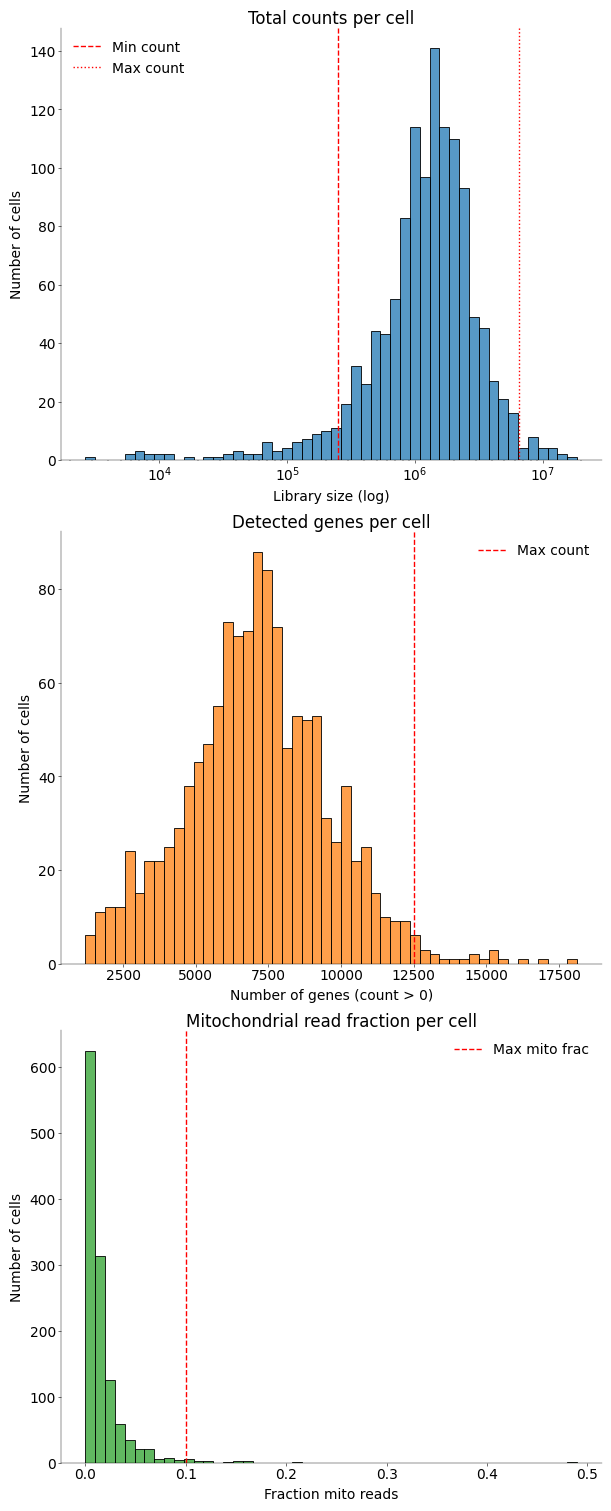

In [19]:
# RUN THIS

# 4. Plot histograms of per-cell metrics
fig, axs = plt.subplots(3, 1, figsize=(6, 15))

# Total counts per cell
sns.histplot(total_counts, bins=50, log_scale=(True, False), ax=axs[0])
min_count_thresh = 2.5 * 1e5
max_count_thresh = 6.5 * 1e6
axs[0].axvline(
    min_count_thresh, color="red", linestyle="--", label="Min count"
)
axs[0].axvline(max_count_thresh, color="red", linestyle=":", label="Max count")
axs[0].set_title("Total counts per cell")
axs[0].set_xlabel("Library size (log)")
axs[0].set_ylabel("Number of cells")
axs[0].legend()

# Number of detected genes per cell
sns.histplot(n_genes, bins=50, ax=axs[1], color="C1")
max_n_genes_thresh = 12500
axs[1].axvline(
    max_n_genes_thresh, color="red", linestyle="--", label="Max count"
)
axs[1].set_title("Detected genes per cell")
axs[1].set_xlabel("Number of genes (count > 0)")
axs[1].set_ylabel("Number of cells")
axs[1].legend()

# Mitochondrial fraction per cell
sns.histplot(mito_frac, bins=50, ax=axs[2], color="C2")
max_mito_frac_thresh = 0.1
axs[2].axvline(
    max_mito_frac_thresh, color="red", linestyle="--", label="Max mito frac"
)
axs[2].set_title("Mitochondrial read fraction per cell")
axs[2].set_xlabel("Fraction mito reads")
axs[2].set_ylabel("Number of cells")
axs[2].legend()

plt.show()


**Total Counts per Cell (Library Size)**
- **Observation**: Peaks around 10⁶ reads; wide range from ~10⁴ to >10⁷.
- **Filter rationale**:
  - **$< 2.5×10^5$**: Likely empty droplets or failed captures → high noise, dropout.
  - **$> 6.5×10^6$**: Potential doublets → abnormally high total RNA from merged cells.

**Detected Genes per Cell**
- **Observation**: Most cells have 6 000–8 000 genes; tails on both sides.
- **Filter rationale**:
  - **> 12,500 genes**: Likely doublets → combined gene sets from multiple cells.

**Mitochondrial Read Fraction**
- **Observation**: Most cells < 5%; some above 10% up to 50%.
- **Filter rationale**:
  - **> 10% mito reads**: Damaged/dying cells → stress-related expression, technical artifacts.

Overall, these filters remove low-quality or non-single-cell profiles and improve normalization, variance modeling, clustering, and overall interpretability.


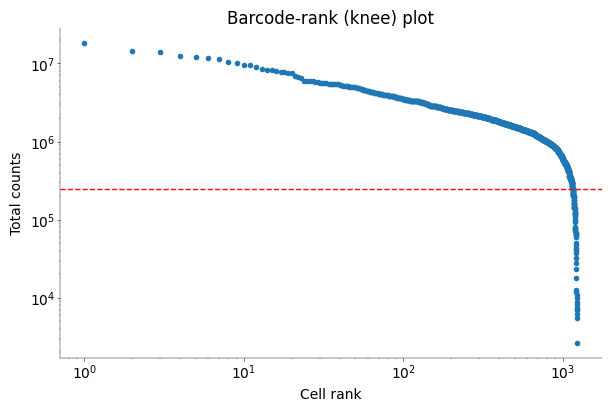

In [20]:
# 5. Barcode‐rank ("knee") plot
sorted_counts = np.sort(total_counts.values)[::-1]
ranks = np.arange(1, len(sorted_counts) + 1)
plt.figure(figsize=(6, 4))
plt.loglog(ranks, sorted_counts, marker=".", linestyle="none")
plt.xlabel("Cell rank")
plt.ylabel("Total counts")
plt.title("Barcode‐rank (knee) plot")
plt.axhline(y=min_count_thresh, color="red", linestyle="--")
plt.show()

This plot shows total RNA counts per cell ranked in descending order. The sharp drop ("knee") around rank 1,100 separates high-quality cells from low-quality ones. Cells after the knee are likely low-quality captures, empty droplets, or damaged cells with degraded RNA. The wide range in counts (~20×) suggests we should use normalization methods that account for large library size differences (e.g., DESeq2, TMM, or scran). The top few barcodes may be doublets due to abnormally high counts.

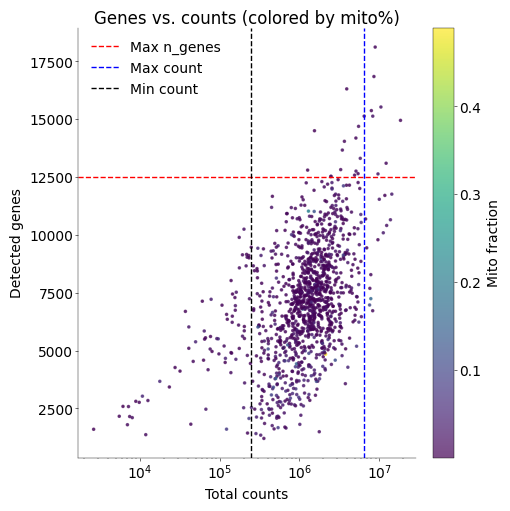

In [21]:
# 6. Scatter: detected genes vs. counts colored by mitochondrial fraction
plt.figure(figsize=(5, 5))
plt.scatter(
    total_counts, n_genes, c=mito_frac, cmap="viridis", s=10, alpha=0.7
)
plt.colorbar(label="Mito fraction")
plt.xlabel("Total counts")
plt.ylabel("Detected genes")
plt.title("Genes vs. counts (colored by mito%)")
plt.axhline(
    y=max_n_genes_thresh, color="red", linestyle="--", label="Max n_genes"
)
plt.axvline(
    x=max_count_thresh, color="blue", linestyle="--", label="Max count"
)
plt.axvline(
    x=min_count_thresh, color="black", linestyle="--", label="Min count"
)
plt.legend()
plt.xscale("log")
plt.show()

This plot shows a clear positive correlation between total counts and the number of detected genes per cell, as expected.  
Most cells cluster tightly between $10^5$–$10^7$ reads and 5,000–10,000 genes, with low mitochondrial fractions (< 0.1), indicating high-quality captures.  

A few cells in the bottom-left have low counts, low gene numbers, and elevated mito%, suggesting damaged or dying cells—these should be filtered out.  
A small group in the top-right with very high counts and gene numbers are likely doublets and should be flagged for removal or inspection.


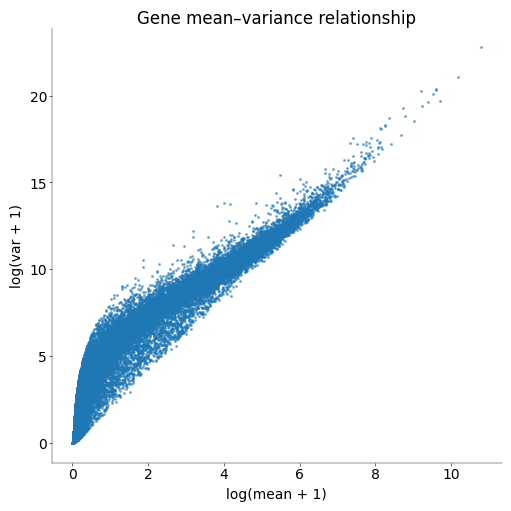

In [22]:
# 7. Gene‐level statistics
gene_means = df_counts.mean(axis=0)
gene_vars = df_counts.var(axis=0)
dropout_rate = (df_counts == 0).sum(axis=0) / df_counts.shape[0]

# 7a. Mean–variance relationship (log–log)
plt.figure(figsize=(5, 5))
plt.scatter(np.log1p(gene_means), np.log1p(gene_vars), s=5, alpha=0.5)
plt.xlabel("log(mean + 1)")
plt.ylabel("log(var + 1)")
plt.title("Gene mean–variance relationship")
plt.show()

This plot shows a strong positive relationship between mean and variance, with variance clearly exceeding the mean across most genes. This confirms that our data is over‑dispersed, as expected for raw read counts (not UMI-based), which include amplification noise and biological variability. A Poisson model would underestimate this variance, so downstream steps, such as highly variable gene selection or NB-mixture clustering, should use models or transforms that account for over-dispersion.

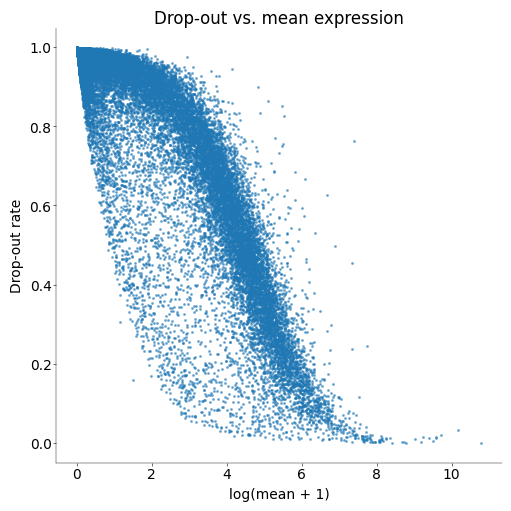

In [23]:
# 7b. Drop‐out rate vs. mean expression
plt.figure(figsize=(5, 5))
plt.scatter(np.log1p(gene_means), dropout_rate, s=5, alpha=0.5)
plt.xlabel("log(mean + 1)")
plt.ylabel("Drop‐out rate")
plt.title("Drop‐out vs. mean expression")
plt.show()

**Drop-out vs. mean expression:**
This plot shows the expected “L”-shaped relationship: genes with low average expression drop out in nearly all cells, while highly expressed genes are detected more consistently.

* Genes **above** the main curve (higher drop-out than expected) may be poorly captured or spurious, and are candidates for filtering.
* Genes **below** the curve (lower drop-out than expected) are often strong, cell-type–specific markers and should be retained.

The smooth decay and lack of anomalous outliers suggest sensible capture and alignment. Based on this, we can safely filter out genes with very low mean expression (e.g., log(mean+1) < 1) or drop-out rates above 95% before selecting highly variable genes.


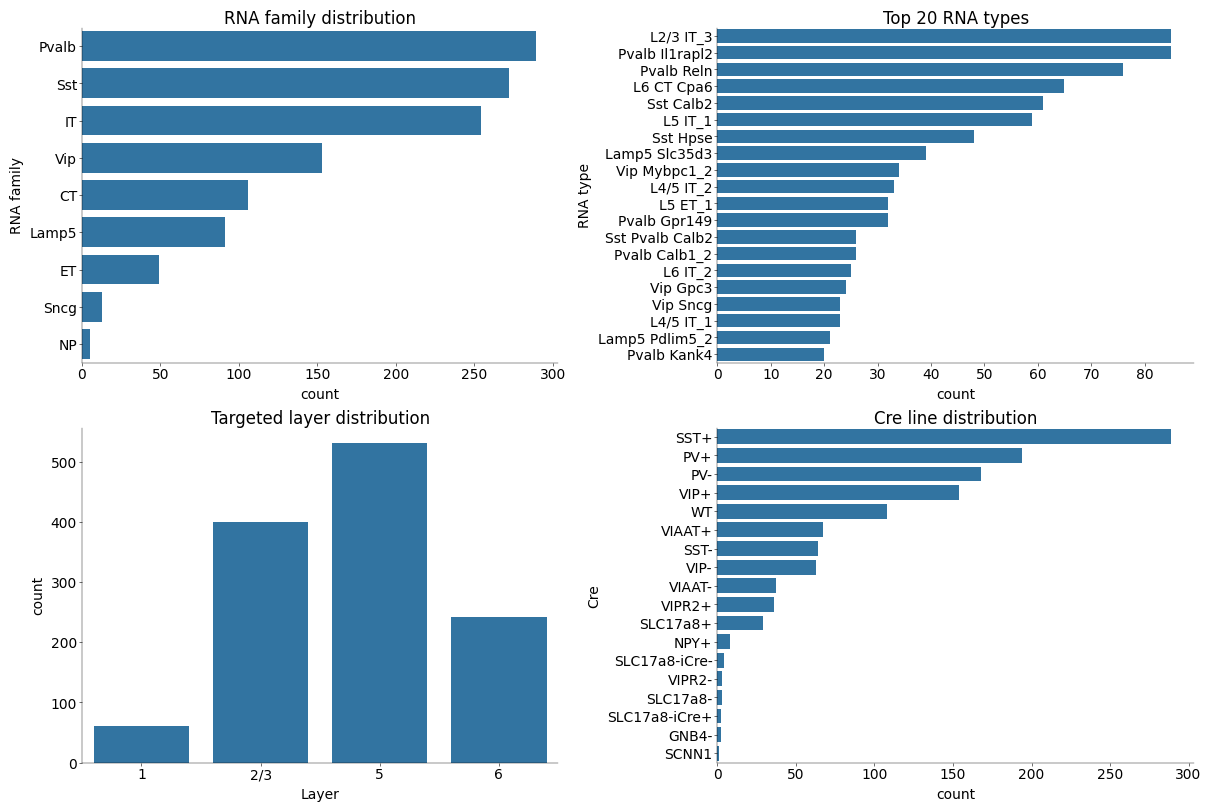

In [24]:
# 8. Plot metadata distributions for external validation
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# RNA family
sns.countplot(
    y="RNA family",
    data=meta_qc,
    order=meta_qc["RNA family"].value_counts().index,
    ax=axs[0, 0],
)
axs[0, 0].set_title("RNA family distribution")

# RNA type (subset top 20 for readability)
top_types = meta_qc["RNA type"].value_counts().nlargest(20).index
sns.countplot(
    y="RNA type",
    data=meta_qc[meta_qc["RNA type"].isin(top_types)],
    order=top_types,
    ax=axs[0, 1],
)
axs[0, 1].set_title("Top 20 RNA types")

# Targeted layer
sns.countplot(
    x="Targeted layer",
    data=meta_qc,
    order=sorted(meta_qc["Targeted layer"].unique()),
    ax=axs[1, 0],
)
axs[1, 0].set_title("Targeted layer distribution")
axs[1, 0].set_xlabel("Layer")

# Cre line
sns.countplot(
    y="Cre",
    data=meta_qc,
    order=meta_qc["Cre"].value_counts().index,
    ax=axs[1, 1],
)
axs[1, 1].set_title("Cre line distribution")

plt.show()

- **RNA Family Distribution:** The dataset is heavily imbalanced, with three families—**Pvalb**, **Sst**, and **IT**—making up the majority of the cells. In contrast, families such as **Sncg** and **NP** are extremely rare. This imbalance affects clustering validation and classification metrics, as dominant families can overwhelm signal from rare types. For downstream analysis, especially when evaluating clustering or differential expression, it may be necessary to filter or downsample to ensure fair representation.

- **RNA Type Distribution:** While there are 77 distinct RNA types, most are represented by very few cells. Even within the top 20 types, the number of cells per type varies widely (e.g., from ~90 down to ~20). This long-tailed distribution makes it difficult to use RNA type labels reliably for clustering validation. It may be more meaningful to validate at the RNA **family** level or group very rare types into an "Other" category.

- **Targeted Layer Distribution:** The vast majority of cells are from cortical layers **2/3**, **5**, and **6**, with almost very few from layer 1. This sampling bias implies that any observed transcriptomic gradients may reflect anatomical sampling (e.g., 2/3 $\to$ 5 $\to$ 6) rather than biological continua. It also means we cannot draw any conclusions about layer 1.

- **Cre Line Distribution:** The dataset includes several dominant Cre lines (e.g., **SST$^+$**, **PV$^⁺$**, **VIP$^⁺$**), but many others are represented by very few cells. This suggests that Cre line identity may act as a confounding batch effect in some analyses. In visualizations like PCA or UMAP, coloring by Cre line can help detect such artefactual structure. When using Cre information for external validation, it's best to focus on the larger groups.

**Conclusion:** These metadata patterns highlight strong group imbalances and sampling biases in the dataset. In all downstream analyses (normalization, visualization, clustering, and validation) these imbalances must be taken into account. Most importantly, validation should be done at the **RNA family** level (9 groups), rather than using the full 77 RNA types, due to the extreme class imbalance and sparsity.


In [25]:
# RUN THIS

# Compute removals
removed_low = np.sum(total_counts < min_count_thresh)
removed_high = np.sum(total_counts > max_count_thresh)
removed_high_genes = np.sum(n_genes > max_n_genes_thresh)
removed_mito = np.sum(mito_frac > max_mito_frac_thresh)

n_cells = len(meta_qc)
print(f"Total cells before QC: {n_cells}")
print(
    f"  - Removed {removed_low} cells with < {min_count_thresh:.0f} reads "
    f"({removed_low/n_cells:.1%})"
)
print(
    f"  - Removed {removed_high} cells with > {max_count_thresh:.0f} reads "
    f"({removed_high/n_cells:.1%})"
)
print(
    f"  - Removed {removed_high_genes} cells with > {max_n_genes_thresh} genes "
    f"({removed_high_genes/n_cells:.1%})"
)
print(
    f"  - Removed {removed_mito} cells with mito fraction > {max_mito_frac_thresh:.0%} "
    f"({removed_mito/n_cells:.1%})"
)

# Build the combined “keep” mask
keep_mask = (
    (total_counts >= min_count_thresh)
    & (total_counts <= max_count_thresh)
    & (n_genes <= max_n_genes_thresh)
    & (mito_frac <= max_mito_frac_thresh)
)

# Report final counts
n_keep = keep_mask.sum()
print(
    f"Cells passing all filters: {n_keep} / {n_cells} ({n_keep/n_cells:.1%})\n"
)

Total cells before QC: 1232
  - Removed 78 cells with < 250000 reads (6.3%)
  - Removed 22 cells with > 6500000 reads (1.8%)
  - Removed 23 cells with > 12500 genes (1.9%)
  - Removed 17 cells with mito fraction > 10% (1.4%)
Cells passing all filters: 1102 / 1232 (89.4%)



In [26]:
# RUN THIS

exonCounts = exonCounts[keep_mask, :]
meta_qc = meta_qc[keep_mask.values]
df_counts = df_counts[keep_mask]

In [27]:
meta_qc.isna().any(axis=0)

Number                      False
Cell                        False
Slice                       False
Date                        False
Sample                      False
Mouse                       False
Mouse date of birth         False
Mouse age                   False
Mouse gender                False
Mouse genotype              False
Targeted layer              False
Inferred layer              False
Cre                         False
Exon reads                  False
Intron reads                False
Intergenic reads            False
Sequencing batch            False
Number of genes detected    False
RNA family                  False
RNA type                    False
RNA type confidence         False
RNA type top-3              False
ALM/VISp top-3              False
Length (bp)                 False
Yield (pg/µl)                True
User                        False
Hold Time (min)              True
Soma depth (µm)              True
Soma depth (4x)              True
Cortical thick

We compute how many cells are filtered out based on quality control thresholds for RNA content:

1. Total counts: We remove cells with very low total reads (< min threshold),
   which likely represent empty droplets or failed captures, and very high counts (> max threshold),
   which may indicate doublets or multiplets (i.e., multiple cells sequenced together).

2. Detected genes: We remove cells expressing an abnormally high number of genes,
   another indicator of doublets where gene expression from multiple cells is merged.

3. Mitochondrial fraction: We remove cells with a high percentage of mitochondrial reads,
   a common marker of stressed or dying cells. These cells often show degraded transcriptomes
   and distort downstream analyses.

These filters are applied jointly to build a boolean mask (`keep_mask`) identifying high-quality,
single-cell profiles. This conservative filtering improves normalization, variance modeling,
clustering, and interpretability throughout the pipeline.


In [28]:
# RUN THIS

# 1) Compute per‐gene mean (on CPM or raw counts)
gene_means = exonCounts.mean(axis=0)

# 2) Build a boolean mask of genes to keep
keep = np.ones_like(gene_means, dtype=bool)
#   a) drop very low‐expressed
keep &= gene_means > 0.1
#   b) drop mito
keep &= ~np.char.startswith(genes.astype(str), "MT-")
#   c) drop ribosomal
keep &= ~(
    np.char.startswith(genes.astype(str), "Rps")
    | np.char.startswith(genes.astype(str), "Rpl")
)

exonCounts = exonCounts[:, keep]
exonLengths = exonLengths[keep]
genes = genes[keep]

We apply the following gene-level filters to clean up the feature space before selecting HVGs:

1. Drop very lowly expressed genes (`gene_means > 0.1`)
   Rationale: Genes with extremely low expression carry little information about cellular identity
   and are dominated by sampling noise. Removing them reduces the multiple-testing burden,
   speeds up downstream steps, and prevents spuriously high dispersion scores for near-zero means.
   This aligns with best practices (Luecken & Theis, 2019), which recommend filtering genes not
   expressed in enough cells.

2. Drop mitochondrial genes (`~startswith("MT-")`)
   Rationale: Mitochondrial transcripts reflect stress, apoptosis, or ambient RNA rather than
   biological variation. They often score highly for variance due to cell damage, not cell type.
   Removing them ensures HVGs reflect meaningful biological signal. This is consistent with the
   practice of ignoring strongly ambient genes in downstream steps.

3. Drop ribosomal genes (`~(startswith("Rps") | startswith("Rpl"))`)
   Rationale: Ribosomal protein genes are highly and broadly expressed housekeeping genes.
   Their variability is often technical or prep-related and not informative for distinguishing
   cell types. Removing them ensures HVG selection focuses on relevant biology, not general
   translation machinery. This fits the broader recommendation to remove technical covariates
   before feature selection.

These filters refine our gene set to focus on informative, biologically meaningful variation
and are fully consistent with current best practices in single-cell analysis.


### 1.2 - Electrophysiology

---
## 2 - Normalize & transform the data; select genes & apply PCA

There are several ways of normalizing the RNA count data (Raw, CPM, CPMedian, RPKM, see https://www.reneshbedre.com/blog/expression_units.html, https://translational-medicine.biomedcentral.com/articles/10.1186/s12967-021-02936-w). Take into account that there are certain normalizations that only make sense for UMI data, but not for this read count data. You also explored different transformations in the assignment (none, log, sqrt). Compare how the different transformations change the two-dimensional visualization. After normalization and transformation, choose a set of highly variable genes (as demonstrated in the lecture) and apply PCA. Play with the number of selected genes and the number of PCA components, and again compare their effects on the two-dimensional visualization.

1. Yes— scran is a third, single‑cell–focused method for estimating size factors, alongside DESeq2’s median‑of‑ratios and edgeR’s TMM. The key difference is:

    DESeq2 / TMM were designed for bulk RNA‑seq, where each sample has relatively shallow sparsity. They estimate each cell’s or sample’s scaling factor by comparing it to a reference (geometric mean across all samples for DESeq2; a median‑size reference for TMM) and trimming or down‑weighting extreme genes.

    scran (Lun et al., 2016) is built for very sparse single‑cell data. It pools small groups of cells together to form “pseudo‑bulk” samples, estimates size factors on those pools (where the data are dense enough), and then deconvolves back to individual cells.

        Why scran? In scRNA‑seq you often have many zeros (drop‑outs), so directly computing ratios or M‑values per cell can be unstable. Pooling borrows strength across cells to get more reliable estimates.

In [37]:
# RUN THIS


# Normalization functions
def cpm_norm(counts):
    return counts / counts.sum(axis=1, keepdims=True) * 1e6


def cpm_median_norm(counts):
    """
    CPMedian normalization: like CPM but scaling by the median library size
    (total counts) across all cells instead of 1e6.

    counts: array of shape (n_cells, n_genes)
    returns: array of same shape, normalized counts
    """
    # total counts per cell
    lib_sizes = counts.sum(axis=1, keepdims=True)
    # median library size (scalar)
    median_size = np.median(lib_sizes)
    # avoid division by zero
    # lib_sizes[lib_sizes == 0] = np.nan
    # normalize each cell by its library size, then scale up to the median
    return counts / lib_sizes * median_size


def rpkm_norm(counts, exon_lengths_bp):
    """
    RPKM normalization: Reads Per Kilobase per Million mapped reads.

    counts:           array of shape (n_cells, n_genes)
    exon_lengths_bp:  1‑d array of length n_genes, gene lengths in base pairs

    RPKM = counts * 1e9 / (length_bp * total_counts_per_cell)
    """
    # total counts per cell
    lib_sizes = counts.sum(axis=1, keepdims=True)
    # lib_sizes[lib_sizes == 0] = np.nan

    # broadcast gene lengths to shape (1, n_genes)
    lengths = exon_lengths_bp[None, :]
    # avoid division by zero
    # lengths[lengths == 0] = np.nan

    # compute RPKM
    return counts * 1e9 / (lengths * lib_sizes)


def deseq2_norm_manual(counts, min_cells=3, eps=1e-8):

    # keep genes with some minimal expression
    gene_mask = (counts > 0).sum(axis=0) >= min_cells
    X = counts[:, gene_mask]
    # geometric mean of each kept gene across cells
    gm = np.exp(np.mean(np.log(X + eps), axis=0))
    # make sure gm is never zero
    gm[gm == 0] = np.nan

    # ratios for every cell / gene
    ratios = X / gm
    # size factor per cell = median of (non‑zero) ratios
    size_factors = np.nanmedian(ratios, axis=1)
    # guard against cells with all‑zero genes after filtering
    size_factors[np.isnan(size_factors) | (size_factors == 0)] = 1.0
    # divide original counts (not the subset) by its cell’s size factor
    return counts / size_factors[:, None]


def deseq2_norm(counts):
    normalized_counts, size_factors = pydeseq2_norm(exonCounts)
    return normalized_counts


counts_dict = {
    "raw": exonCounts.copy(),
    "CPM": cpm_norm(exonCounts),
    "CPMedian": cpm_median_norm(exonCounts),
    "RPKM": rpkm_norm(exonCounts, exonLengths),
    "DESeq2": deseq2_norm(exonCounts),
}

# Transformations
transforms = {
    "linear": lambda X: X,
    "sqrt": lambda X: np.sqrt(X),
    "log1p": lambda X: np.log1p(X),
}

# Pre-compute all normalized and transformed matrices
#    keys are tuples (norm_name, tfm_name)
transformed_data = {}
for norm_name, counts in counts_dict.items():
    for tfm_name, tfm in transforms.items():
        transformed_data[(norm_name, tfm_name)] = tfm(counts)


# HVG selection function
def select_hvg(X, n_top=2000, n_bins=20):
    """
    Manual HVG selection: bin by mean, z‑score dispersion within each bin.
    """
    mu = np.nanmean(X, axis=0)
    var = np.nanvar(X, axis=0, ddof=1)
    disp = var / (mu + 1e-12)

    # Bin genes by mean (dropping NaN means)
    valid = ~np.isnan(mu)
    bins = pd.qcut(mu[valid], q=n_bins, labels=False, duplicates="drop")
    disp_z = np.zeros_like(disp)
    for b in np.unique(bins):
        idx_b = np.where(valid)[0][bins == b]
        d_b = disp[idx_b]
        m, s = d_b.mean(), d_b.std(ddof=1)
        if s > 0:
            disp_z[idx_b] = (d_b - m) / s
        else:
            disp_z[idx_b] = 0.0

    # pick top
    n_select = min(n_top, disp_z.size)
    return np.argsort(disp_z)[-n_select:]


# PCA + Metrics
def run_pca_metrics(X, n_hvg=2000, n_pc=20):
    hvg_idx = select_hvg(X, n_hvg)
    X_hvg = X[:, hvg_idx]
    X_scaled = StandardScaler().fit_transform(X_hvg)
    pca = PCA(n_components=n_pc)
    pcs = pca.fit_transform(X_scaled)
    return {
        "pcs": pcs,
        "var_ratio": pca.explained_variance_ratio_,
    }


# Grid Search
hvg_sizes = [500, 1000, 2000]
n_pc_list = [10, 20, 50]

results = {}
for (norm_name, tfm_name), X_tfm in transformed_data.items():
    for n_hvg in hvg_sizes:
        for n_pc in n_pc_list:
            key = (norm_name, tfm_name, n_hvg, n_pc)
            results[key] = run_pca_metrics(X_tfm, n_hvg=n_hvg, n_pc=n_pc)

In [38]:
for key, val in transformed_data.items():
    if np.any(~np.isfinite(val)) or np.any(np.isnan(val)):
        print(key)

In [39]:
for key, val in results.items():
    if np.any(~np.isfinite(val["pcs"])) > 0 or np.any(np.isnan(val["pcs"])):
        print(key)

For Task 2, we made the following choices to ensure that our PCA reflects true biological variation rather than technical artifacts:

1. **Normalization**
   We use **DESeq2 size‑factor** normalization in addtion to simple CPM/RPKM/TPM because DESeq2 corrects not only for total read depth but also for compositional differences (i.e. when a few genes dominate the library). Zhao et al. (2021) showed that median‑of‑ratios (DESeq2) and TMM produce the lowest coefficient of variation and best clustering of biological replicates, whereas TPM/FPKM can be distorted by highly expressed genes. However **CPM, CPMedian, and RPKM** are still included as a baseline.

2. **Variance‑stabilising transformation**
   After normalization, counts remain skewed (many zeros, few very large values). We apply **$\log(1+x)$** (and compare to $\sqrt x$ or linear) because $\log$ compresses extremes and approximates normality, which makes PCA more meaningful. Square‑root is a milder alternative, and leaving the data untransformed reveals whether skew still dominates the PCs.

3. **Highly Variable Gene (HVG) selection**
   With tens of thousands of genes, most contribute only noise. We rank genes by their dispersion (variance/mean) across cells and select the top N (e.g. 2 000), focusing PCA on the features that drive real cell‑to‑cell differences.

4. **PCA on scaled HVGs**
   Finally, we z‑score each selected gene and run PCA (choosing 10, 20, or 50 components).

Each of these steps—robust normalization, log transform, HVG filtering, and PCA—builds on best practices for RNA‑seq visualization and is grounded in the evidence presented by Zhao et al.

**Note:** We postpone 2D visualizations (e.g., PCA scatter plots) to **Task 3**, which explicitly focuses on comparing dimensionality reduction methods (PCA, t-SNE, UMAP) and evaluating them using quantitative metrics as suggested in Lause et al. (2024). Since Task 3 includes both visualization and metric-based comparison, we avoid redundancy and defer all 2D embedding plots to that section.

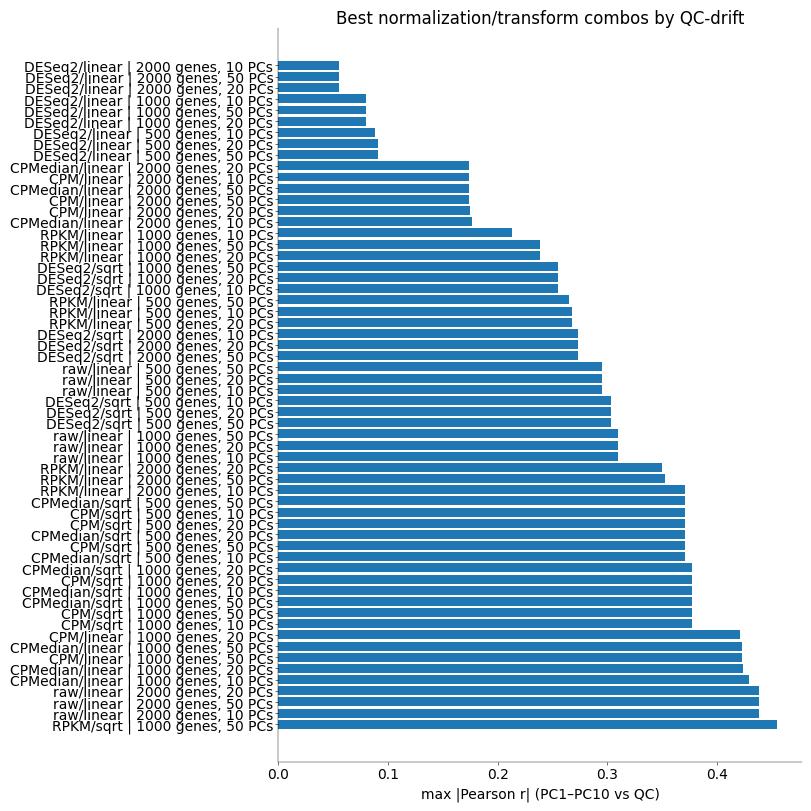

In [47]:
def compute_pc_qc_corr(pcs, qc_df, n_pcs=10):
    """
    pcs:      array of shape (n_cells, n_components)
    qc_df:    DataFrame of shape (n_cells, n_qc_metrics)
    n_pcs:    how many leading PCs to correlate

    Returns a DataFrame of shape (n_qc_metrics, n_pcs) whose (i,j) entry
    is corr( qc_df[col_i], pcs[:, j] ).
    """
    # 1) build a DataFrame for the first n_pcs
    pc_cols = [f"PC{j+1}" for j in range(n_pcs)]
    pcs_df = pd.DataFrame(pcs[:, :n_pcs], index=qc_df.index, columns=pc_cols)

    # 2) select only the numeric QC columns
    qc_numeric = qc_df.select_dtypes(include=[np.number])

    # 3) concat and compute full correlation matrix
    combined = pd.concat([pcs_df, qc_numeric], axis=1)
    corr_mat = combined.corr()

    # 4) extract the submatrix: rows = QC metrics, cols = PCs
    return corr_mat.loc[qc_numeric.columns, pc_cols]


def summarize_qc_drift(results, qc_df, n_pcs=10):
    rows = []
    for key, res in results.items():
        pcs = res["pcs"]
        # compute corr for first n_pcs
        corr = compute_pc_qc_corr(pcs, qc_df, n_pcs=n_pcs).abs()
        rows.append(
            {
                "norm": key[0],
                "transform": key[1],
                "n_hvg": key[2],
                "n_pc": key[3],
                "max_abs_r": corr.values.max(),
                "mean_abs_r": corr.values.mean(),
            }
        )
    return pd.DataFrame(rows)


summary_df = summarize_qc_drift(
    results, meta_qc[["total_counts", "n_genes", "mito_frac"]], n_pcs=10
)

# combine columns into a label
summary_df["label"] = (
    summary_df["norm"]
    + "/"
    + summary_df["transform"]
    + " | "
    + summary_df["n_hvg"].astype(str)
    + " genes, "
    + summary_df["n_pc"].astype(str)
    + " PCs"
)

# pick the top 10 best (lowest max_abs_r)
best10 = summary_df.nsmallest(60, "max_abs_r")

# plot
plt.figure(figsize=(8, 8))
plt.barh(best10["label"], best10["max_abs_r"])
plt.xlabel("max |Pearson r| (PC1–PC10 vs QC)")
plt.title("Best normalization/transform combos by QC‑drift")
plt.gca().invert_yaxis()
plt.show()

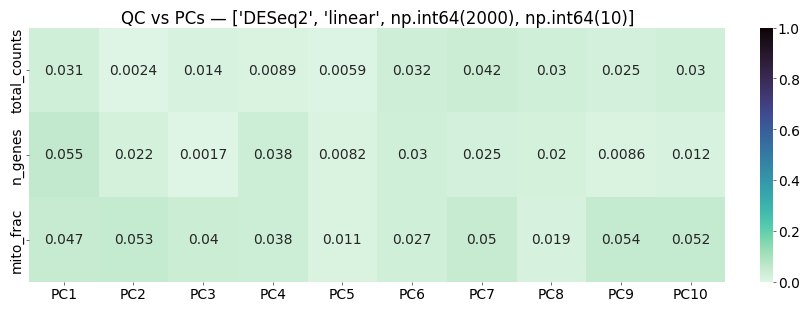

In [43]:
best_key = best10.iloc[0][["norm", "transform", "n_hvg", "n_pc"]].tolist()
pcs = results[tuple(best_key)]["pcs"]
corr_df = compute_pc_qc_corr(
    pcs, meta_qc[["total_counts", "n_genes", "mito_frac"]], n_pcs=10
)

plt.figure(figsize=(8, 3))
sns.heatmap(corr_df.abs(), annot=True, cmap="mako_r", vmin=0, vmax=1)
plt.title(f"QC vs PCs — {best_key}")
plt.show()

In [53]:
K = 100
best_keys = [
    tuple(r)
    for r in summary_df.nsmallest(K, "max_abs_r")[
        ["norm", "transform", "n_hvg", "n_pc"]
    ].values
]

# filter your results and adjust total_runs
filtered_results = {key: results[key] for key in best_keys}

**QC-Drift Analysis**

Before applying non-linear dimensionality reduction (e.g. t-SNE, UMAP), it is essential to ensure that the PCA representation is not dominated by technical artifacts such as:

- **Library size** (`total_counts`)
- **Number of detected genes** (`n_genes`)
- **Mitochondrial read fraction** (`mito_frac`)

If we skip this step, downstream 2D visualizations may misleadingly reflect sequencing quality rather than true biological structure.

To address this, we compute **Pearson correlations between the top principal components and these QC metrics**. For each preprocessing pipeline—defined by normalization method, transformation, number of highly variable genes (HVG), and number of PCA components—we measure:

- **`max_abs_r`**: the worst-case correlation (maximum absolute r across all PCs and QC metrics)
- **`mean_abs_r`**: the average absolute correlation (overall leakage)

This **QC-drift score** serves two key purposes:

1. **Validation**: It helps identify the *cleanest* PCA representations—those least confounded by technical noise—making them better foundations for downstream analysis.

2. **Filtering**: It drastically **reduces the embedding search space**.  
   Rather than applying t-SNE/UMAP to all normalization/transform/HVG/PCA combinations, we **restrict to the top-K lowest-drift pipelines**, which:
   - Speeds up computation
   - Focuses effort on meaningful, biologically driven embeddings
   - Avoids overfitting to artifacts like library size or mitochondrial bias

By applying QC-drift filtering before the embedding step, we ensure that our visualizations are both more **efficient** and more **biologically interpretable**.


---
## 3 - Two-dimensional visualization

To visualize the RNA count data after normalization, transformation, gene selection and PCA, try different methods (just PCA, t-SNE, UMAP, ..) and vary their parameters (exaggeration, perplexity, ..). Compare them using quantitative metrics (e.g., kNN accuracy in high-dim vs. two-dim, kNN recall). Please refer to Lause et al., 2024 (https://doi.org/10.1371/journal.pcbi.1012403) where many of these metrics are discussed and explained to make an informed choice on which metrics to use. Think about also using the electrophysiological features and other metadata to enhance different visualizations.

In [57]:
# Encode RNA families for coloring
le = LabelEncoder()
fam_labels = le.fit_transform(meta_qc["RNA family"])
fam_categories = le.classes_

In [58]:
# --- 8) two‑dimensional embeddings & evaluation --------------------------------
warnings.filterwarnings(
    "ignore",
    message=".*'force_all_finite' was renamed to 'ensure_all_finite'.*",
    category=FutureWarning,
)

# 8.1) registry of embedding methods
embed_fns = {
    "PCA2D": lambda P, **kw: PCA(n_components=2, **kw).fit_transform(P),
    "tSNE": lambda P, **kw: TSNE(n_components=2, **kw).fit_transform(P),
    "UMAP": lambda P, **kw: umap.UMAP(n_components=2, **kw).fit_transform(P),
}

# 8.2) hyper‑parameter grid
embed_params = []
# PCA‑2D baseline
embed_params.append(("PCA2D", {}))

# t‑SNE sweep
for perp in [5, 10, 30]:
    for exag in [4, 12]:
        embed_params.append(
            (
                "tSNE",
                {
                    "perplexity": perp,
                    "early_exaggeration": exag,
                    "learning_rate": "auto",
                    "init": "pca",
                    "random_state": 0,
                },
            )
        )

# UMAP sweep
for nnb in [15, 30]:
    for dist in [0.1, 0.5]:
        embed_params.append(
            (
                "UMAP",
                {
                    "n_neighbors": nnb,
                    "min_dist": dist,
                    "metric": "euclidean",
                    "random_state": 0,
                },
            )
        )


# 8.3) evaluation function for one 2D embedding
def evaluate_embedding(Y2d, labels, NN_hd, P_hd, k=10):
    # 2D neighbors
    NN_2d = (
        NearestNeighbors(n_neighbors=k)
        .fit(Y2d)
        .kneighbors(return_distance=False)
    )
    # kNN accuracy (label purity)
    preds = np.array([np.bincount(labels[nn]).argmax() for nn in NN_2d])
    knn_acc = (preds == labels).mean()
    # kNN recall (continuity)
    knn_recall = np.mean(
        [
            len(set(NN_hd[i]).intersection(NN_2d[i])) / k
            for i in range(len(labels))
        ]
    )
    # silhouette in 2D
    sil = silhouette_score(Y2d, labels)
    # trustworthiness
    trust = sk_trustworthiness(P_hd, Y2d, n_neighbors=k)
    # AMI via HDBSCAN
    clust = hdbscan.HDBSCAN(min_cluster_size=30).fit(Y2d)
    ami = adjusted_mutual_info_score(labels, clust.labels_)
    return dict(
        knn_acc=knn_acc,
        knn_recall=knn_recall,
        silhouette=sil,
        trust=trust,
        ami=ami,
    )


parallel = True
total_runs = len(filtered_results) * len(embed_params)
print(f"Total runs {total_runs}")
if not parallel:
    # 8.4) run embeddings & collect metrics
    embedding_results = {}

    # compute total number of runs
    run_counter = 1

    for key, pca_out in filtered_results.items():
        # pca_out['pcs'] is the HD representation of shape (n_cells, n_pc)
        P_hd = pca_out["pcs"]
        # precompute HD neighbor graph
        NN_hd = (
            NearestNeighbors(n_neighbors=10)
            .fit(P_hd)
            .kneighbors(return_distance=False)
        )

        for method, params in embed_params:
            print(
                f"[{run_counter}/{total_runs}] "
                f"Config={key} → Embedding={method}, params={params}"
            )

            # perform embedding
            Y2d = embed_fns[method](P_hd, **params)

            # evaluate
            metrics = evaluate_embedding(Y2d, fam_labels, NN_hd, P_hd, k=10)
            embedding_results[(key, method, tuple(sorted(params.items())))] = (
                metrics
            )

            print(
                f"    → Done: knn_acc={metrics['knn_acc']:.3f}, "
                f"knn_recall={metrics['knn_recall']:.3f}, "
                f"silhouette={metrics['silhouette']:.3f}, "
                f"trust={metrics['trust']:.3f}, ami={metrics['ami']:.3f}\n"
            )

            run_counter += 1

    print("All embeddings evaluated.")

    rows = []
    for (
        (norm, tfm, n_hvg, n_pc),
        method,
        params_tuple,
    ) in embedding_results.keys():
        # collect the metric dict
        met = embedding_results[(norm, tfm, n_hvg, n_pc), method, params_tuple]
        rows.append(
            {
                "norm": norm,
                "tfm": tfm,
                "n_hvg": n_hvg,
                "n_pc": n_pc,
                "method": method,
                "params": dict(params_tuple),
                **met,
            }
        )

    df_embed = pd.DataFrame(rows)
else:

    # 1) Precompute PCA outputs and HD neighbor graphs once
    hd_data = {}
    for key, pca_out in filtered_results.items():
        P_hd = pca_out["pcs"]
        NN_hd = (
            NearestNeighbors(n_neighbors=10)
            .fit(P_hd)
            .kneighbors(return_distance=False)
        )
        hd_data[key] = (P_hd, NN_hd)

    # 2) Build a flat list of all (key, method, params) jobs
    jobs = [
        (key, P_hd, NN_hd, method, params)
        for key, (P_hd, NN_hd) in hd_data.items()
        for method, params in embed_params
    ]

    # 3) Define worker
    def run_job(key, P_hd, NN_hd, method, params):
        Y2d = embed_fns[method](P_hd, **params)
        metrics = evaluate_embedding(Y2d, fam_labels, NN_hd, P_hd, k=10)
        return key, method, params, metrics

    # 4) Dispatch in parallel
    job_results = Parallel(n_jobs=6, verbose=10)(
        delayed(run_job)(key, P_hd, NN_hd, method, params)
        for key, P_hd, NN_hd, method, params in jobs
    )

    # 5) Reassemble into DataFrame
    rows = []
    for key, method, params, met in job_results:
        norm, tfm, n_hvg, n_pc = key
        rows.append(
            {
                "norm": norm,
                "tfm": tfm,
                "n_hvg": n_hvg,
                "n_pc": n_pc,
                "method": method,
                "params": params,
                **met,
            }
        )

    df_embed = pd.DataFrame(rows)

Total runs 1100


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:   17.5s
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:   34.9s
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed:  1.0min
[Parallel(n_jobs=6)]: Done  20 tasks      | elapsed:  1.3min
[Parallel(n_jobs=6)]: Done  29 tasks      | elapsed:  1.7min
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:  2.1min
[Parallel(n_jobs=6)]: Done  49 tasks      | elapsed:  2.5min
[Parallel(n_jobs=6)]: Done  60 tasks      | elapsed:  2.8min
[Parallel(n_jobs=6)]: Done  73 tasks      | elapsed:  3.2min
[Parallel(n_jobs=6)]: Done  86 tasks      | elapsed:  3.6min
[Parallel(n_jobs=6)]: Done 101 tasks      | elapsed:  4.1min
[Parallel(n_jobs=6)]: Done 116 tasks      | elapsed:  4.5min
[Parallel(n_jobs=6)]: Done 133 tasks      | elapsed:  5.0min
[Parallel(n_jobs=6)]: Done 150 tasks      | elapsed:  5.5min
[Parallel(n_jobs=6)]: Done 169 tasks      | elapsed:  6.2min
[Parallel(

In [59]:
# rank each metric (higher better) and add mean rank
for col in ["knn_acc", "knn_recall", "silhouette", "trust", "ami"]:
    df_embed[f"{col}_rank"] = df_embed[col].rank(ascending=False)
df_embed["mean_rank"] = df_embed[
    [c for c in df_embed.columns if c.endswith("_rank")]
].mean(axis=1)

# final sorted table
df_embed = df_embed.sort_values("trust_rank").reset_index(drop=True)

df_embed.head(5)

,norm,tfm,n_hvg,n_pc,method,params,knn_acc,knn_recall,silhouette,trust,ami,knn_acc_rank,knn_recall_rank,silhouette_rank,trust_rank,ami_rank,mean_rank
0,CPMedian,log1p,1000,10,tSNE,"{'perplexity': 30, 'early_exaggeration': 4, 'l...",0.910163,0.636025,0.177586,0.992789,0.570665,255.0,10.0,407.0,1.0,307.0,196.0
1,CPM,sqrt,2000,10,tSNE,"{'perplexity': 30, 'early_exaggeration': 4, 'l...",0.929220,0.645281,0.229487,0.992763,0.393660,142.5,3.0,239.0,2.0,652.5,207.8
2,CPMedian,sqrt,2000,10,tSNE,"{'perplexity': 30, 'early_exaggeration': 4, 'l...",0.930127,0.639655,0.230006,0.992655,0.393660,136.5,7.0,235.0,3.0,652.5,206.8
3,CPM,sqrt,2000,10,tSNE,"{'perplexity': 30, 'early_exaggeration': 12, '...",0.924682,0.642740,0.250573,0.992590,0.393660,157.5,4.0,167.0,4.0,652.5,197.0
4,CPM,sqrt,2000,10,tSNE,"{'perplexity': 10, 'early_exaggeration': 12, '...",0.926497,0.622505,0.228721,0.992331,0.565327,151.0,20.0,243.0,5.0,320.5,147.9



=== Embedding Rank #1 ===
norm = 'CPMedian'
transform = 'log1p'
n_hvg = 1000, n_pc = 10
method = tSNE
params = {'perplexity': 30, 'early_exaggeration': 4, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



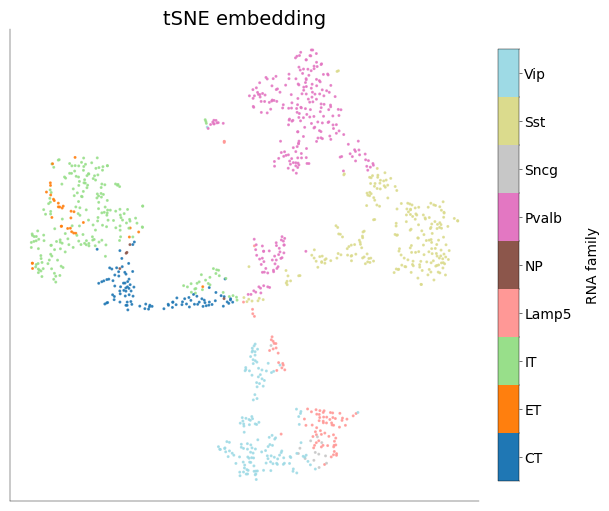


=== Embedding Rank #2 ===
norm = 'CPM'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 30, 'early_exaggeration': 4, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



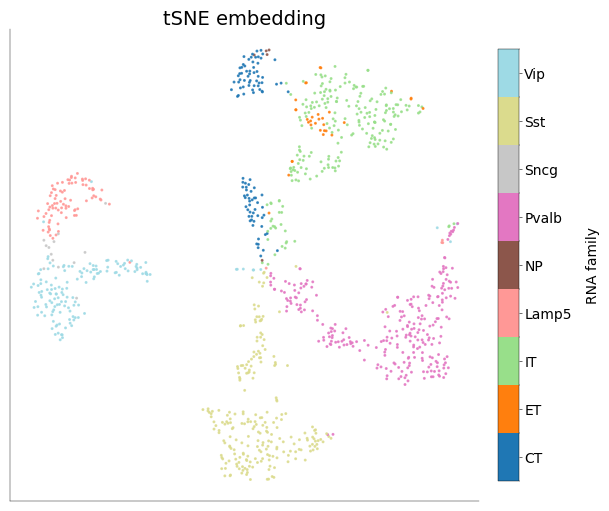


=== Embedding Rank #3 ===
norm = 'CPMedian'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 30, 'early_exaggeration': 4, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



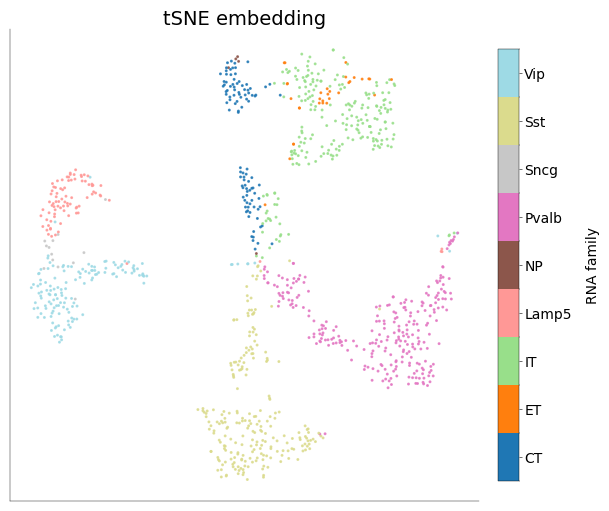


=== Embedding Rank #4 ===
norm = 'CPM'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 30, 'early_exaggeration': 12, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



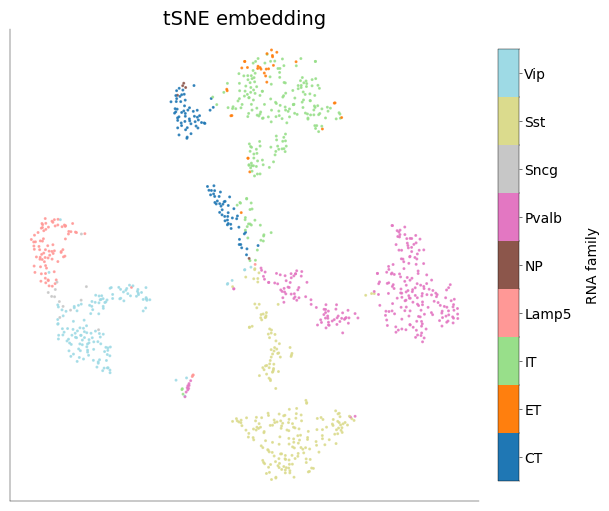


=== Embedding Rank #5 ===
norm = 'CPM'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 10, 'early_exaggeration': 12, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



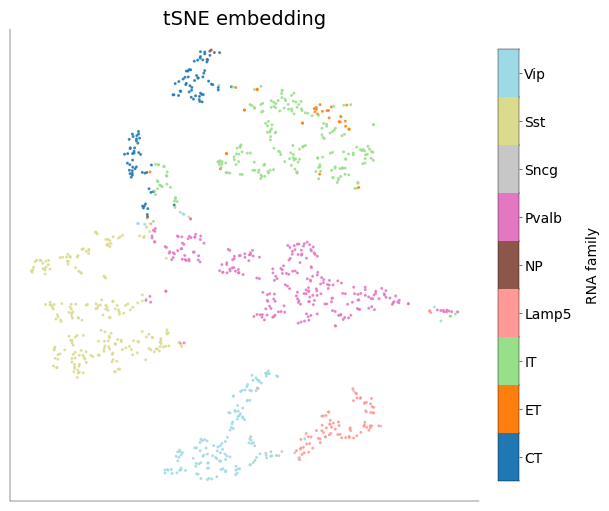


=== Embedding Rank #6 ===
norm = 'CPMedian'
transform = 'log1p'
n_hvg = 1000, n_pc = 10
method = tSNE
params = {'perplexity': 30, 'early_exaggeration': 12, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



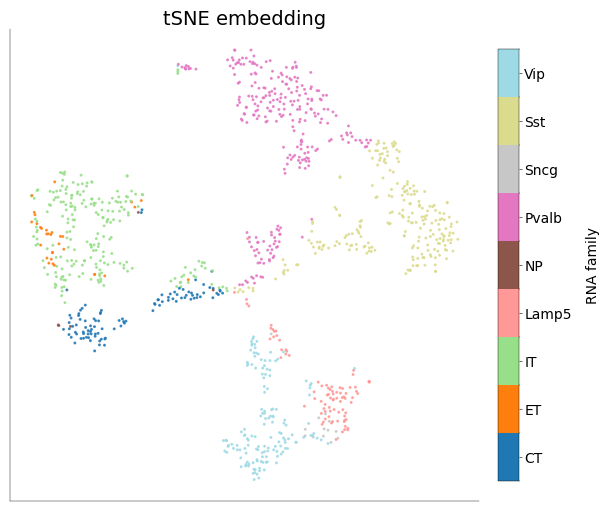


=== Embedding Rank #7 ===
norm = 'CPMedian'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 10, 'early_exaggeration': 4, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



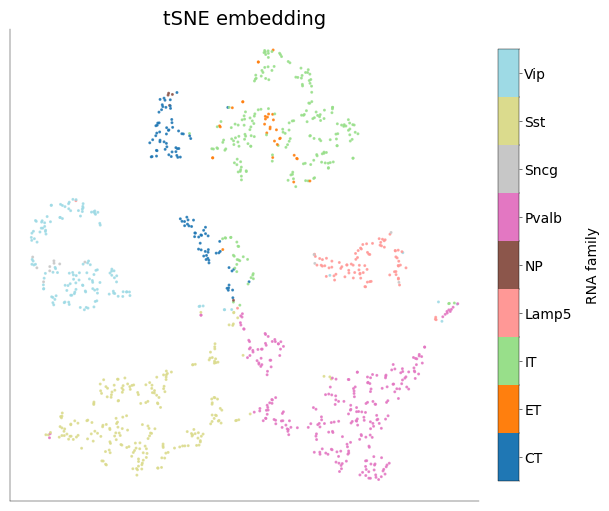


=== Embedding Rank #8 ===
norm = 'CPMedian'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 30, 'early_exaggeration': 12, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



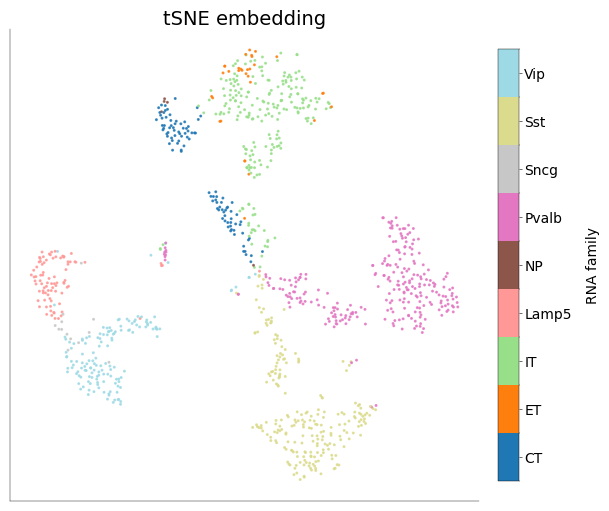


=== Embedding Rank #9 ===
norm = 'CPMedian'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 10, 'early_exaggeration': 12, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



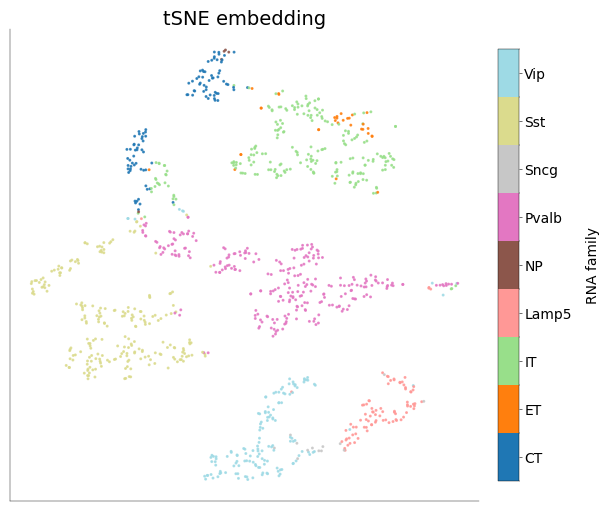


=== Embedding Rank #10 ===
norm = 'CPMedian'
transform = 'log1p'
n_hvg = 1000, n_pc = 10
method = tSNE
params = {'perplexity': 10, 'early_exaggeration': 4, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



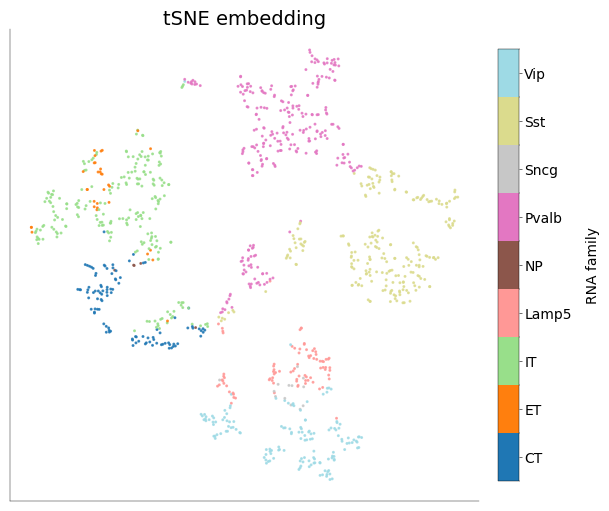

In [60]:
# how many categories?
n_cats = len(fam_categories)

# discrete colormap + norm
cmap = plt.get_cmap("tab20", n_cats)
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(-0.5, n_cats + 0.5, 1), ncolors=n_cats
)

top_n = 10
top_df = df_embed.head(top_n)

for rank, (_, row) in enumerate(top_df.iterrows(), start=1):
    # 1) print all the info
    print(f"\n=== Embedding Rank #{rank} ===")
    print(f"norm = {row['norm']!r}")
    print(f"transform = {row['tfm']!r}")
    print(f"n_hvg = {row['n_hvg']}, n_pc = {row['n_pc']}")
    print(f"method = {row['method']}")
    print(f"params = {row['params']}\n")

    # 2) recover the high‑dim PCs and compute 2D embedding
    key = (row["norm"], row["tfm"], row["n_hvg"], row["n_pc"])
    P_hd = filtered_results[key]["pcs"]
    Y2d = embed_fns[row["method"]](P_hd, **row["params"])

    # 3) fresh figure + scatter
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(
        Y2d[:, 0],
        Y2d[:, 1],
        c=fam_labels,
        cmap=cmap,
        norm=norm,
        s=5,
        alpha=0.8,
    )
    ax.set_title(f"{row['method']} embedding", fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

    # 4) discrete colorbar with family names
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # no actual data needed
    cbar = fig.colorbar(
        sm, ax=ax, ticks=np.arange(n_cats), fraction=0.046, pad=0.04
    )
    cbar.ax.set_yticklabels(fam_categories)
    cbar.set_label("RNA family", rotation=90, labelpad=10)

    plt.show()

Having completed normalization, transformation, variable‑gene selection and PCA (Task 2), we now face the challenge of **displaying** our high‑dimensional transcriptomic space in two dimensions. Traditionally, inspection of scatterplots is done by eye, looking for islands of cell types, but with dozens of preprocessing variants and embedding hyperparameters, visual inspection alone is neither scalable nor objective. We therefore automate a **quantitative search** for the best 2‑D map, using the metrics and recommendations from Lause *et al.* (2024) .

**1. Embedding methods under consideration**

* **PCA‑2D**: a linear baseline projecting directly onto the first two principal components.
* **t‑SNE**: preserves local neighborhoods via pairwise affinities; key hyperparameters include *perplexity* and *early exaggeration*.
* **UMAP**: balances local and global structure by approximating a Riemannian manifold; varied by *n\_neighbors* and *min\_dist*.

By sweeping each method over a grid of recommended hyperparameters, we generate a diverse set of candidate embeddings.

**2. Objective evaluation metrics**

**Lause *et al.* (2024)** systematically compare embeddings using metrics that capture both **neighborhood fidelity** and **cluster structure**. We adopt their core set, plus a complementary cluster‐agreement score:

1. **k‑NN accuracy**
   Fraction of each cell’s *k* nearest neighbors in 2D that share the same RNA‑family label—i.e. local label purity .
2. **k‑NN recall** (a.k.a. *continuity*)
   Fraction of a cell’s *k* neighbors in the high‑dimensional (PCA) space that remain neighbors in 2D.
3. **Silhouette coefficient**
   Measures how well cells of the same label form compact, separated clusters in the 2D layout.
4. **Trustworthiness**
   Penalizes “false” 2D neighbors that were not close in the original high‑dimensional space; computed as in Lee & Verleysen (2009) .
5. **Adjusted Mutual Information (AMI)**
   Agreement between an *unsupervised* clustering of the 2D map (e.g. HDBSCAN) and the RNA‑family labels.

By combining **label‑dependent** (1, 3, 5) and **label‑independent** (2, 4) criteria, we guard against “over‑fitting” to potentially noisy annotations while still rewarding clear, biologically meaningful separations.

**3. Workflow outline**

1. **Reference space freeze**
   Choose one normalized & transformed gene set (e.g. top 2000 HVGs, 50 PCs) and compute its *k*‑NN graph once.
2. **Grid generation**
   For each embedding method, iterate over its hyperparameter grid to produce 2D coordinates.
3. **Metric computation**
   For every 2D map, compute the five metrics above, using the frozen high‑dimensional graph for continuity/trustworthiness.
4. **Aggregate & rank**
   Either rank each embedding on each metric and compute a mean rank, or normalize metrics to \[0, 1] and form a weighted sum.
5. **Select winner**
   The top‑ranked embedding provides an objective choice for visualization, reproducing Lause *et al.*’s finding that properly‑tuned t‑SNE/UMAP often dramatically outperform PCA‑2D in local purity and cluster separation .


By following this **principled, metric‑driven** pipeline, we obtain a reproducible, defensible choice of 2D projection.


In [65]:
def get_top_unique_datasets(df_embed, top_n):
    top = df_embed.head(top_n)
    seen = set()
    unique = []
    for _, row in top.iterrows():
        ds = (row["norm"], row["tfm"], row["n_hvg"], row["n_pc"])
        if ds not in seen:
            seen.add(ds)
            unique.append(ds)
    print(f"From top {top_n} embeddings → {len(unique)} unique datasets")
    for ds in unique:
        print(f"  • {ds}")
    return unique


def fetch_dataset_matrices(df_embed, transformed_data, results, top_n=10):
    """
    Returns a dict:
      { (norm,tfm,n_hvg,n_pc): { 'X_tfm':…, 'P_hd':… }, … }
    for the first top_n ranked embeddings (deduped by dataset).
    """
    unique_ds = get_top_unique_datasets(df_embed, top_n)
    ds_data = {}
    for ds in unique_ds:
        norm, tfm, n_hvg, n_pc = ds

        # your normalized+transformed counts
        X_tfm = transformed_data[(norm, tfm)]

        # the PCA‐scores (n_cells × n_pc)
        P_hd = results[(norm, tfm, n_hvg, n_pc)]["pcs"]

        ds_data[ds] = {"X_tfm": X_tfm, "P_hd": P_hd}
    return ds_data


unique_ds_data = fetch_dataset_matrices(
    df_embed, transformed_data, filtered_results, top_n=20
)

From top 20 embeddings → 8 unique datasets
  • ('CPMedian', 'log1p', 1000, 10)
  • ('CPM', 'sqrt', 2000, 10)
  • ('CPMedian', 'sqrt', 2000, 10)
  • ('raw', 'log1p', 1000, 10)
  • ('CPMedian', 'sqrt', 1000, 10)
  • ('CPM', 'sqrt', 1000, 10)
  • ('CPMedian', 'log1p', 500, 10)
  • ('RPKM', 'log1p', 1000, 10)


In [66]:
# RUN THIS
dataset_lst = [
    ("CPMedian", "log1p", 1000, 10),
    ("CPM", "sqrt", 2000, 10),
    ("CPMedian", "sqrt", 2000, 10),
    ("raw", "log1p", 1000, 10),
    ("CPMedian", "sqrt", 1000, 10),
    ("CPM", "sqrt", 1000, 10),
    ("CPMedian", "log1p", 500, 10),
    ("RPKM", "log1p", 1000, 10),
]

unique_ds_data = {}

for ds in dataset_lst:
    norm, tfm, n_hvg, n_pc = ds

    # your normalized+transformed counts
    X_tfm = transformed_data[(norm, tfm)]

    # the PCA‐scores (n_cells × n_pc)
    P_hd = filtered_results[(norm, tfm, n_hvg, n_pc)]["pcs"]

    unique_ds_data[ds] = {"X_tfm": X_tfm, "P_hd": P_hd}

---
# 4 - Clustering
To find cell types in the RNA count data, you will need to look for clusters. Try different clustering methods (leiden, GMM). Implement a negative binomial mixture model. For that you can follow a similar method that what is described in Harris et al. 2018 (https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.2006387#abstract0), with fixed r (r=2). Feel free to simplify the setup from the paper and not optimize over the set of important genes S but fix it instead, or skip the split and merge part of their clustering algorithm. A vanilla NBMM implementation should suffice. Take into account that the NBMM tries to cluster data that follows a negative binomial distribution. Therefore, it does not make sense to apply this clustering method to all kinds of normalized and transformed data. Please refer to the Harris et al. 2018 publication for the appropriate choice of normalization, and reflect on why this normalization makes sense. Evaluate your clustering results (metrics, compare number of clusters to original labels,...).

---
# 5- Correlation between electrophysiological features and genes/PCs

Finally, connect RNA counts and functional data: Most likely, there will be interesting relationships between the transcriptomic and electrophyiological features in this data. Find these correlations and a way of visualizing them. In studying correlations using the PCA-reduced version of the transcriptomics data, it could be interesting to study PC loadings to see which genes are dominating which PCs. For other advanced analyses, you can get inspitation from Kobak et al., 2021 (https://doi.org/10.1111/rssc.12494).